# Statistical test of the excited neutrino hypothesis using the mono-V CMS data

- This notebook builds the likelihood function using the HEPData of the CMS mono-V search, and performs a statistical test of the excited neutrino hypothesis.

- HEPData: https://www.hepdata.net/record/ins1894408  

- Paper: https://cms-results.web.cern.ch/cms-results/public-results/publications/EXO-20-004/index.html  



# Import the yields - both the background prediction and the observed data

- The yields are read from `monov_yields.yaml` file, which has the following structure:

```yaml
dependent_variables:
- header:
    name: Background yield
  values:
  - value: 9812.890625
  - value: 6159.333038
  ...

- header:
    name: Data yield
  values:
  - value: 9929
  - value: 6057
  ...

independent_variables:
- header:
    name: Bin
  values:
  - value: monovtau21_2016_bin0
  - value: monovtau21_2016_bin1
  ...
```

In [1]:
# Read the yaml file.
import yaml
with open("data/monoj_yields.yaml", "r") as f:
    monov_yields = yaml.safe_load(f)

# Read the bin names, background yields, and data yields,
# excluding the 2016 bins.
monov_bkg = []
monov_data = []
bin_names = []
for index in range(len(monov_yields['independent_variables'][0]['values'])):
    bin_name = monov_yields['independent_variables'][0]['values'][index]['value']
    if '2016' not in bin_name:
        bin_names.append(bin_name)
        monov_bkg.append(monov_yields['dependent_variables'][0]['values'][index]['value'])
        monov_data.append(monov_yields['dependent_variables'][1]['values'][index]['value'])

for bin_name, bkg, data in zip(bin_names, monov_bkg, monov_data):
    print(f"{bin_name}: bkg = {bkg}, data = {data}")

monojet_2017_bin0: bkg = 169737.7734, data = 176171
monojet_2017_bin1: bkg = 93266.63818, data = 96067
monojet_2017_bin2: bkg = 54175.54321, data = 54789
monojet_2017_bin3: bkg = 32232.16919, data = 32767
monojet_2017_bin4: bkg = 19798.24585, data = 20209
monojet_2017_bin5: bkg = 12816.66046, data = 12910
monojet_2017_bin6: bkg = 10626.91895, data = 10653
monojet_2017_bin7: bkg = 6407.873535, data = 6487
monojet_2017_bin8: bkg = 3903.657227, data = 3955
monojet_2017_bin9: bkg = 2519.861908, data = 2587
monojet_2017_bin10: bkg = 1929.788399, data = 1957
monojet_2017_bin11: bkg = 1181.808949, data = 1151
monojet_2017_bin12: bkg = 713.7919903, data = 721
monojet_2017_bin13: bkg = 456.2266827, data = 455
monojet_2017_bin14: bkg = 294.6278095, data = 298
monojet_2017_bin15: bkg = 231.1669064, data = 244
monojet_2017_bin16: bkg = 146.4085865, data = 146
monojet_2017_bin17: bkg = 87.26129293, data = 89
monojet_2017_bin18: bkg = 69.26482379, data = 65
monojet_2017_bin19: bkg = 32.26833493, dat

# Import the covariance matrix

- The covariance matrix is read from `monov_cov.yaml` file, which had the following structure:

```yaml
dependent_variables:
- header:
    name: Covariance
  values:
  - value: 77980.32004
  - value: 27279.25967
  ...

independent_variables:
- header:
    name: First Bin
  values:
  - value: monovtau21_2016_bin0
  - value: monovtau21_2016_bin0
  ...

- header:
    name: Second Bin
  values:
  - value: monovtau21_2016_bin0
  - value: monovtau21_2016_bin1
  ...
```

In [2]:
# Read the mono-V covariance matrix from the file monov_cov.yaml.
import yaml
import numpy as np
with open("data/monoj_cov.yaml", "r") as f:
    monov_cov = yaml.safe_load(f)

In [3]:
# Check that the order of bins in the covariance matrix matches the order of bins in the yields file.
bin_names_2 = []
for var in monov_cov['independent_variables'][0]['values']:
    name = var['value']
    if name not in bin_names_2 and '2016' not in name:
        bin_names_2.append(name)

assert bin_names_2 == bin_names

In [4]:
# Create the covariance matrix as a 2D numpy array, where the order of rows and columns corresponds to the order of bin names in the list created above.
cov_ndarray = np.zeros((len(bin_names), len(bin_names)))
for i, var1 in enumerate(bin_names):
    for j, var2 in enumerate(bin_names):
        # Find the covariance element for var1 and var2 in monov_cov and store it in cov_ndarray[i, j].
        for row_index in range(len(monov_cov['independent_variables'][0]['values'])):
            tmp_var1 = monov_cov['independent_variables'][0]['values'][row_index]['value']
            tmp_var2 = monov_cov['independent_variables'][1]['values'][row_index]['value']
            if (tmp_var1 == var1 and tmp_var2 == var2):
                cov_ndarray[i, j] = monov_cov['dependent_variables'][0]['values'][row_index]['value']
                break


The cell below just checks that the 2016 bins are discarded correctly.

In [5]:
# Check that the covariance matrix cov_ndarray was read correctly.

def find_index(i1, i2):
    """
    Find the index in monov_cov corresponding to the covariance element between bins with indices i1 and i2 in bin_names.

    The offset of 22 corresponds to the 2016 bins, which are not included in bin_names.
    """
    i1 += 22
    i2 += 22
    return (len(bin_names) + 22) * i1 + i2


from math import isclose
for i1 in range(len(bin_names)):
    for i2 in range(len(bin_names)):
        index = find_index(i1, i2)
        cov_value = cov_ndarray[i1, i2]
        yaml_value = monov_cov['dependent_variables'][0]['values'][index]['value']
        condition = isclose(cov_value, yaml_value, rel_tol=1e-9)
        condition = condition and (monov_cov['independent_variables'][0]['values'][index]['value'] == bin_names[i1])
        condition = condition and (monov_cov['independent_variables'][1]['values'][index]['value'] == bin_names[i2])
        if not condition:
            print(f"Mismatch at i1={i1}, i2={i2}: cov_value={cov_value}, yaml_value={yaml_value}, bin1={monov_cov['independent_variables'][0]['values'][index]['value']}, bin2={monov_cov['independent_variables'][1]['values'][index]['value']}")
            break
else:
    print("All values match.")


All values match.


# Yields read from the "Yields (Monojet)" table in HEPData

In [30]:
import yaml
with open("data/monoj_yields_not_from_simplified_likelihood.yaml", "r") as f:
    alt_yields = yaml.safe_load(f)

# Check the structure of alt_yields and compare the yields in alt_yields with the yields in monov_yields for the bins corresponding to 2017 and 2018.
print(alt_yields['dependent_variables'])


[{'header': {'name': 'Yield'}, 'qualifiers': [{'name': 'Data set year', 'value': 2017}, {'name': 'Category', 'value': 'Monojet'}, {'name': 'Region', 'value': 'Single muon'}, {'name': 'Fit', 'value': 'B-only'}, {'name': 'Process', 'value': 'Data'}], 'values': [{'value': 117100.0}, {'value': 67932.0}, {'value': 41157.0}, {'value': 25640.0}, {'value': 16653.0}, {'value': 10808.0}, {'value': 9347.0}, {'value': 5852.0}, {'value': 3514.0}, {'value': 2436.0}, {'value': 1893.0}, {'value': 1200.0}, {'value': 735.0}, {'value': 495.0}, {'value': 323.0}, {'value': 254.0}, {'value': 156.0}, {'value': 82.0}, {'value': 86.0}, {'value': 41.0}, {'value': 33.0}, {'value': 50.0}]}, {'header': {'name': 'Yield'}, 'qualifiers': [{'name': 'Data set year', 'value': 2017}, {'name': 'Category', 'value': 'Monojet'}, {'name': 'Region', 'value': 'Single muon'}, {'name': 'Fit', 'value': 'B-only'}, {'name': 'Process', 'value': 'QCD multijet'}], 'values': [{'errors': [{'label': 'Total', 'symerror': 1028.4}], 'value':

# Likelihood function

The likelihood function is given by:

$$
-2 \ln L = \sum_{i,j=1}^{n} (m_i - t_i)C^{-1}_{ij} (m_j - t_j)
$$

where $m_i$ are the observed data values (number of counts in the bin $i$), $t_i$ are the predicted values from the background plus signal model, and $C^{-1}_{ij}$ is the inverse of the covariance matrix of the measurement. The matrix $C_{ij}$ is provided by the CMS collaboration.

In the following, we assume that
$$
t_i = t_{i,0} + \sum_p h_{ip}\theta_p
$$
Actually, in our case, $t_{i,0}$ is the background prediction provided by the CMS collaboration, and $h_{ip} = h_{i}$ is the signal prediction for the excited neutrino hypothesis, which can be obtained from the Pythia+Delphes simulation. There is just one parameter $\theta_p = \theta$, which is the signal strength.
$$
\theta_p = \mu \\

h_{ip} = \begin{pmatrix}
h_1 \\
h_2 \\
\vdots \\
\end{pmatrix}
$$

In [6]:
import numpy as np
C = cov_ndarray
m = np.array(monov_data)
t0 = np.array(monov_bkg)
h = np.array([1, 2, 3, 4, 5, 6, 7, 1, 2, 3, 4, 5, 6, 7, 2, 4, 6, 8, 10, 12, 14, 2, 4, 6, 8, 10, 12, 14])
h = np.array([1.006524e+00, 9.487730e-01, 9.858989e-01, 1.056026e+00, 1.072526e+00, 1.167403e+00, 1.485036e+00, 1.592289e+00, 1.612914e+00, 1.678916e+00,  2.165677e+00,  2.330681e+00,  2.211054e+00,  2.145052e+00,  2.025424e+00,  2.392558e+00,  2.149177e+00,  1.827419e+00,  1.905796e+00,  1.563413e+00,  1.518037e+00,  2.037799e+00,
              1.151231e+00,  1.056284e+00,  1.145297e+00,  1.240244e+00,  1.258046e+00,  1.418269e+00,  1.620031e+00,  2.160042e+00,  2.225318e+00,  2.302462e+00,  2.990827e+00,  3.251931e+00,  3.038300e+00,  3.032366e+00,  2.866209e+00,  3.412154e+00,  2.907748e+00,  2.516092e+00,  2.676315e+00,  2.290593e+00,  2.189712e+00,  2.854341e+00])
theta = 0.375

def log_likelihood_factory(h, t0, m, C):
    def log_likelihood(theta):
        d = np.array(m) - (t0 + h * theta)
        return d.T @ np.linalg.inv(C) @ d
        
    return log_likelihood

In [7]:
# Create dictionary with C, m, t0 and pickle it to the file cms_monov_inputs.pkl.
import pickle
inputs = {
    'C': C,
    'm': m,
    't0': t0,
}
with open("data/cms_monoj_inputs.pkl", "wb") as f:
    pickle.dump(inputs, f)

In [8]:
# Remove the second half of fields in m, t0, h and bin_names and the second half of rows and columns in C.
m = m[:len(m)//2]
t0 = t0[:len(t0)//2]
h = h[:len(h)//2]
bin_names = bin_names[:len(bin_names)//2]
C = C[:len(C)//2, :len(C)//2]


Plot the data and the background prediction, and the signal prediction for the excited neutrino hypothesis.

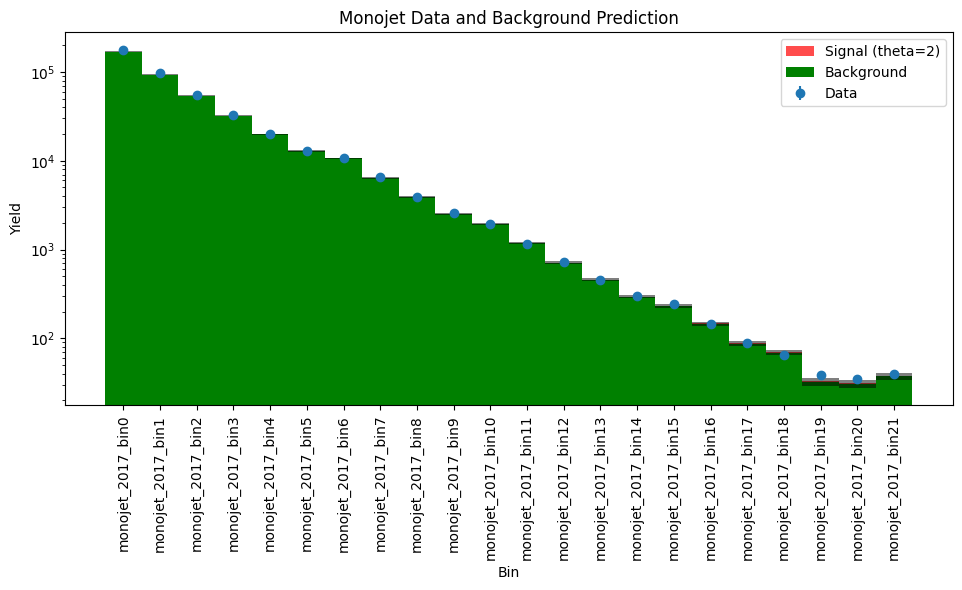

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.errorbar(bin_names, m, yerr=np.sqrt(np.diag(C)), fmt='o', label='Data')
# Plot the signal prediction for the excited neutrino hypothesis, which is given by t0 + h * theta, where theta = 2.
plt.hist(bin_names, weights=t0 + h * theta, bins=np.arange(len(bin_names)+1)-0.5, alpha=0.7, label='Signal (theta=2)', color='red')
plt.hist(bin_names, weights=t0, bins=np.arange(len(bin_names)+1)-0.5, alpha=1, label='Background', color='green')
# Plot the uncertainty on the background prediction as shaded rectangles with centers at the background prediction and heights corresponding to the square root of the diagonal elements of the covariance matrix.
for i in range(len(bin_names)):
    plt.gca().add_patch(plt.Rectangle((i-0.5, t0[i] - np.sqrt(C[i, i])), 1, 2*np.sqrt(C[i, i]), color='black', alpha=0.5, linewidth=0))
plt.xticks(rotation=90)
plt.xlabel('Bin')
plt.ylabel('Yield')
plt.title('Monojet Data and Background Prediction')
plt.legend()
plt.tight_layout()
plt.yscale('log')
plt.show()

Plot the difference between the data and the background prediction, divided by the background uncertainty.

Also, plot the difference divided by the square root of the background yield, which is the Poisson uncertainty of the background yield.

The two graphs above can be shown in the same plot, split into two subplots.

/tmp/ipykernel_167703/3750527102.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_167703/3750527102.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


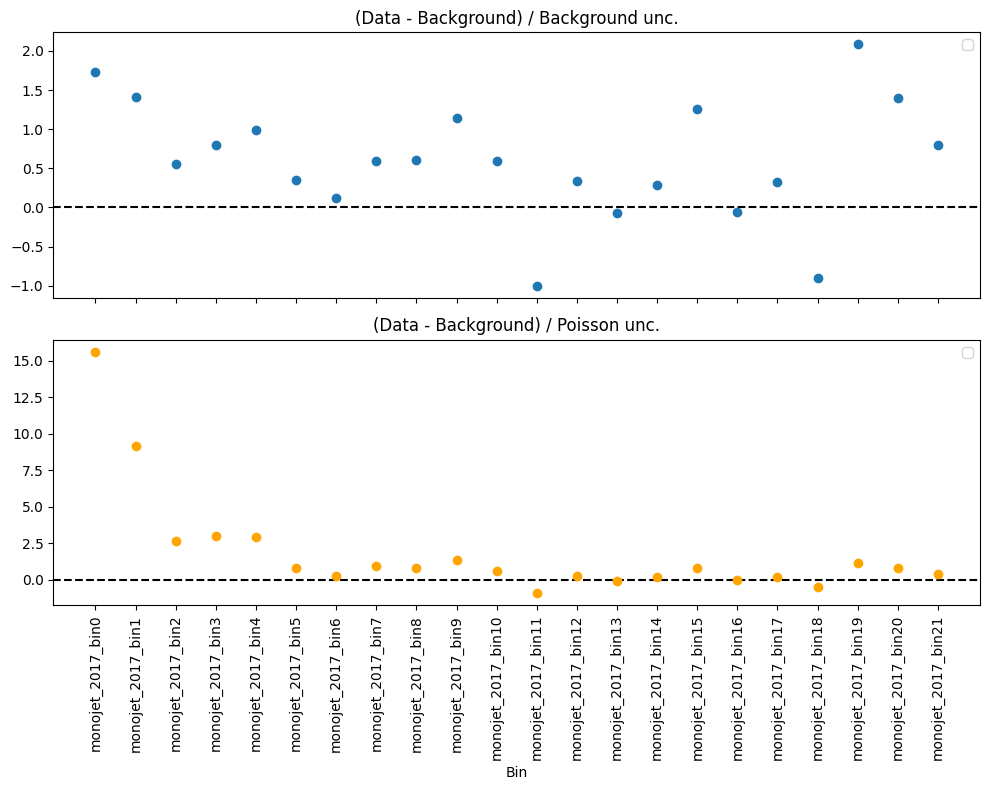

In [10]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# Plot the difference between the data and the background prediction, divided by the background uncertainty.
ax1.errorbar(bin_names, (m - t0) / np.sqrt(np.diag(C)), fmt='o')
ax1.axhline(0, color='black', linestyle='--')
ax1.set_title('(Data - Background) / Background unc.')
ax1.legend()
# Plot the difference between the data and the background prediction, divided by the square root of the background yield, which is the Poisson uncertainty of the background yield.
ax2.errorbar(bin_names, (m - t0) / np.sqrt(t0), fmt='o', color='orange')
ax2.axhline(0, color='black', linestyle='--')
ax2.set_xlabel('Bin')
ax2.set_title('(Data - Background) / Poisson unc.')
ax2.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Find the minimum of the likelihood function with respect to the model parameters.

In [11]:
from iminuit import Minuit

def find_minimum(h, t0, m, C, initial_theta):
    log_likelihood = log_likelihood_factory(h, t0, m, C)
    minuit = Minuit(log_likelihood, np.array([initial_theta]))
    minuit.migrad()
    minuit.hesse()

    # Return the value at the minimum and the uncertainty on that value.
    return minuit.values[0], minuit.errors[0]

def theta_uncertainty(h, t0, m, C, theta):
    log_likelihood = log_likelihood_factory(h, t0, m, C)
    minuit = Minuit(log_likelihood, np.array([theta]))
    minuit.hesse()
    return minuit.errors[0]



We have found the estimator $\hat{\theta}$ and its variance.
As the next step, we will generate pseudo-experiments to determine the distribution of our test statistic, which is:
$$
-2 \ln \lambda(\theta) = -2 \ln \frac{L(\theta)}{L(\hat{\theta})}
$$
Each pseudo-experiment will consist of generating the pseudo-data $m_i$ according to the model with fixed $\theta$ and then computing the test statistic for that pseudo-dataset.

In [12]:
# Generate pseudo-experiments, i.e. the vector m_i.
m_pseudo = np.random.multivariate_normal(mean = t0 + h * theta, cov = C, size = 10000)

Mean of theta_hat: 0.3912979106173011
Standard deviation of theta_hat: 0.9638770514280702
Mean of uncertainties: 0.9767659506758755


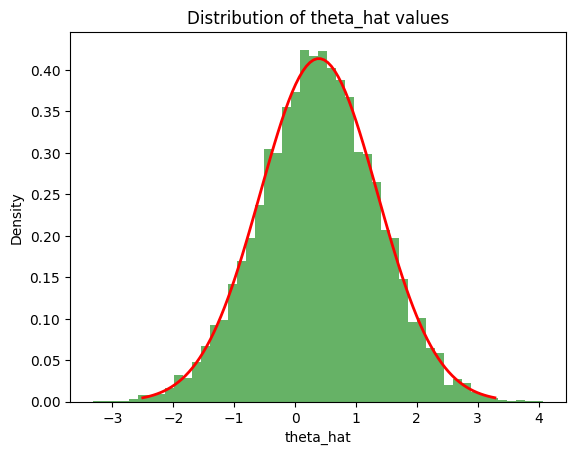

In [13]:
# Check the distribution of the theta_hat values obtained from the pseudo-experiments.
theta_hats = []
uncs = []
for mp in m_pseudo:
    theta_hat, unc = find_minimum(h, t0, mp, C, initial_theta=theta)
    theta_hats.append(theta_hat)
    uncs.append(unc)

# Evaluate the mean and standard deviation of the theta_hat values.
theta_hats = np.array(theta_hats)
mean_theta_hat = np.mean(theta_hats)
std_theta_hat = np.std(theta_hats)
print(f"Mean of theta_hat: {mean_theta_hat}")
print(f"Standard deviation of theta_hat: {std_theta_hat}")
print(f"Mean of uncertainties: {np.mean(uncs)}")

# Draw a histogram of the theta_hat values and compare it to a Gaussian distribution with mean equal to the mean of the theta_hat values and standard deviation equal to the standard deviation of the theta_hat values.
import matplotlib.pyplot as plt
import scipy.stats as stats
plt.hist(theta_hats, bins=50, density=True, alpha=0.6, color='g')
x = np.linspace(mean_theta_hat - 3*std_theta_hat, mean_theta_hat + 3*std_theta_hat, 100)
plt.plot(x, stats.norm.pdf(x, loc=mean_theta_hat, scale=std_theta_hat), 'r-', linewidth=2)
plt.xlabel('theta_hat')
plt.ylabel('Density')
plt.title('Distribution of theta_hat values')
plt.show()

In [14]:
# Compute the test statistic -2*ln(L) for each pseudo-experiment.
# The resulting test_statistic_array array will contain the values of the test statistic for each pseudo-experiment.
def test_statistic(m, C, theta, verbose = False):
    log_likelihood = log_likelihood_factory(h, t0, m, C)
    nll_profile = log_likelihood(theta)
    theta_hat, theta_hat_unc = find_minimum(h, t0, m, C, initial_theta = theta)
    nll_global = log_likelihood(theta_hat)
    if verbose:
        print(f"theta_hat = {theta_hat}, theta_hat_unc = {theta_hat_unc}")
    return nll_profile - nll_global

test_statistic_array = []
for mp in m_pseudo:
    ts = test_statistic(mp, C, theta)
    test_statistic_array.append(ts)


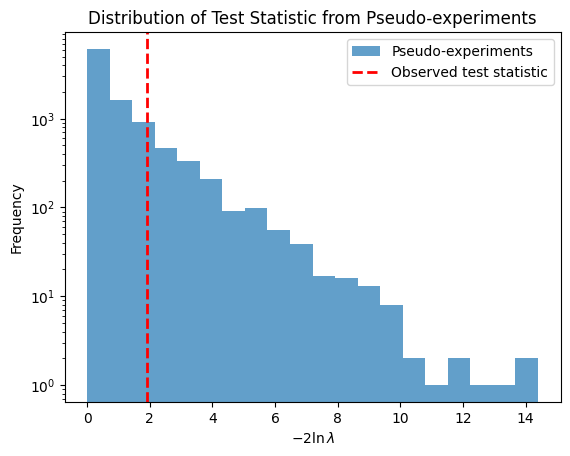

P-value: 0.1628
Significance (Z-score): 0.9830151141820584


In [15]:
# Histogram of the test statistic values from the pseudo-experiments.
# Plot the observed test statistic value (from the original data) as a vertical line to visualize how it compares to the distribution from the pseudo-experiments.
# Use the logarithmic y-axis.
import matplotlib.pyplot as plt
plt.hist(test_statistic_array, bins=20, alpha=0.7, label='Pseudo-experiments')
observed_ts = test_statistic(m, C, theta)
plt.axvline(observed_ts, color='red', linestyle='dashed', linewidth=2, label='Observed test statistic')
plt.xlabel(r'$-2 \ln \lambda$')
plt.ylabel('Frequency')
plt.yscale('log')
plt.title('Distribution of Test Statistic from Pseudo-experiments')
plt.legend()
plt.show()

# Calculate the p-value, which is the probability of observing a test statistic as extreme as (or more extreme than) the observed value under the null hypothesis. This can be done by counting how many pseudo-experiments have a test statistic value greater than or equal to the observed value and dividing by the total number of pseudo-experiments.
p_value = np.sum(test_statistic_array >= observed_ts) / len(test_statistic_array)
print(f'P-value: {p_value}')

# Calculate the significance (Z-score) corresponding to the p-value. The Z-score can be calculated using the inverse cumulative distribution function (CDF) of the standard normal distribution.
from scipy.stats import norm
Z_score = norm.ppf(1 - p_value)
print(f'Significance (Z-score): {Z_score}')

In [16]:
# Calculate the p-value and significance assuming that the test statistic follows a chi-squared distribution with 1 degree of freedom. The p-value can be calculated using the survival function (1 - CDF) of the chi-squared distribution, and the significance can be calculated using the inverse CDF of the standard normal distribution.
from scipy.stats import chi2
p_value_chi2 = chi2.sf(observed_ts, df=1)
Z_score_chi2 = norm.ppf(1 - p_value_chi2)
print(f'P-value (chi-squared): {p_value_chi2}')
print(f'Significance (Z-score, chi-squared): {Z_score_chi2}')

P-value (chi-squared): 0.16788285294271588
Significance (Z-score, chi-squared): 0.9625653248433367


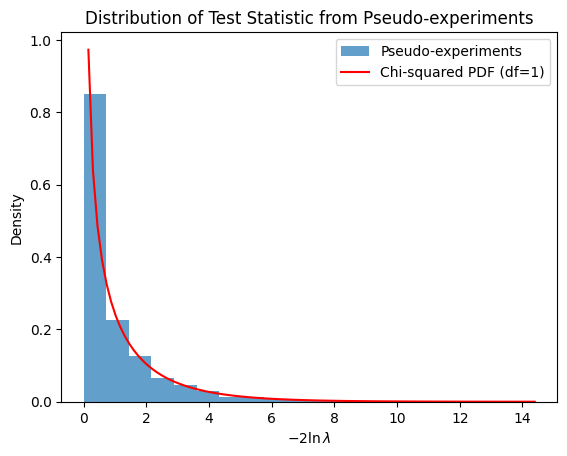

In [17]:
# Compare the distribution of test statistic values from the pseudo-experiments with a chi-squared distribution with 1 degree of freedom.
from scipy.stats import chi2
x = np.linspace(0, max(test_statistic_array), 100)
pdf_chi2 = chi2.pdf(x, df=1)
plt.hist(test_statistic_array, bins=20, density=True, alpha=0.7, label='Pseudo-experiments')
plt.plot(x, pdf_chi2, color='red', label='Chi-squared PDF (df=1)')
plt.xlabel(r'$-2 \ln \lambda$')
plt.ylabel('Density')
plt.title('Distribution of Test Statistic from Pseudo-experiments')
plt.legend()
plt.show()

We have just demonstrated that the p-value and significance calculated using the chi-squared distribution with 1 degree of freedom is a good approximation to the p-value and significance calculated from the pseudo-experiments. This means that we can use the chi-squared distribution to calculate the p-value and significance for our observed test statistic, which is much faster than generating a large number of pseudo-experiments.

In [18]:
# Compute the chi-squared between the test statistic distribution from the pseudo-experiments and the chi-squared distribution with 1 degree of freedom. This can be done by binning the test statistic values from the pseudo-experiments, calculating the expected counts in each bin from the chi-squared distribution, and then using the chi-squared formula to compute the chi-squared value.
observed_counts, bin_edges = np.histogram(test_statistic_array, bins=20)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# integrate the chi-squared PDF over each bin to get the expected counts
expected_counts = chi2.cdf(bin_edges[1:], df=1) - chi2.cdf(bin_edges[:-1], df=1)
expected_counts *= len(test_statistic_array)
# compute the chi-squared value
chi_squared_value = np.sum((observed_counts - expected_counts) ** 2 / expected_counts)
print(f'Chi-squared value: {chi_squared_value}')

Chi-squared value: 31.98728099585737


# Distribution of the test statistic given the background-only hypothesis

As the first step, we will check that the distribution of the test statistic under the background-only hypothesis follows the non-central chi-squared distribution with 1 degree of freedom and non-centrality parameter $\Lambda = (\theta - \theta')^2 / \sigma^2$, where $\theta$ is the tested value, $\theta'$ equals 0 (background-only hypothesis) and $\sigma$ is given by the curvature of the log-likelihood at $\theta'$; to mitigate edge effects, we can use the value of sigma evaluated at any theta value larger than 0.002, as the curvature is the same at any non-zero $\theta$ value.

The check is performed by generating a large number of pseudo-experiments under the background-only hypothesis (i.e., $\theta = 0$) and computing the test statistic for each pseudo-experiment. We then compare the distribution of the test statistic from the pseudo-experiments to the non-central chi-squared distribution with 1 degree of freedom and non-centrality parameter $\Lambda = (\theta - \theta')^2 / \sigma^2$.

In [19]:
# Generate pseudo-experiments, i.e. the vector m_i.
m_pseudo = np.random.multivariate_normal(mean = t0, cov = C, size = 10000)
ts_array_bkg = []
for mp in m_pseudo:
    ts = test_statistic(mp, C, theta)
    ts_array_bkg.append(ts)


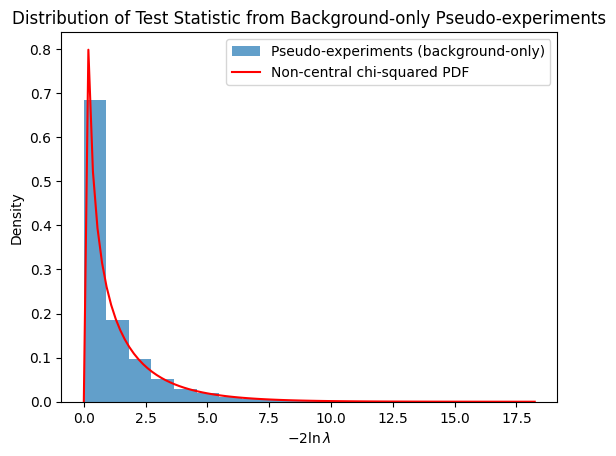

In [20]:
# Plot the spectrum ts_array_bkg.
# Compare it with the non-central chi-squared distribution with 1 degree of freedom and non-centrality parameter Lambda = (theta - theta_prime)^2 / sigma^2, where theta_prime = 0 (background-only hypothesis) and sigma is given by the curvature of the log-likelihood at theta_prime; to mitigate edge effects, we can use the value of sigma evaluated at any theta value larger than 0.002.
import matplotlib.pyplot as plt
from scipy.stats import ncx2
theta_prime = 0
sigma = theta_uncertainty(h, t0, m, C, theta = 0.002)
Lambda = (theta - theta_prime) ** 2 / sigma ** 2
x = np.linspace(0, max(ts_array_bkg), 100)
pdf_ncx2 = ncx2.pdf(x, df=1, nc=Lambda)
plt.hist(ts_array_bkg, bins=20, density=True, alpha=0.7, label='Pseudo-experiments (background-only)')
plt.plot(x, pdf_ncx2, color='red', label=f'Non-central chi-squared PDF')
plt.xlabel(r'$-2 \ln \lambda$')
plt.ylabel('Density')
plt.title('Distribution of Test Statistic from Background-only Pseudo-experiments')
plt.legend()
plt.show()

# CLs value calculation

We know that:

- The test statistic distribution under the signal hypothesis $\theta$ is the chi-squared distribution with 1 degree of freedom.

- The test statistic distribution under the background-only hypothesis $\theta' = 0$ is the non-central chi-squared distribution with 1 degree of freedom and non-centrality parameter $\Lambda = (\theta - \theta')^2 / \sigma^2 = \theta^2 / \sigma^2$; $\sigma$ can be evaluated at any non-zero $\theta$ value, for example at $\theta = \hat{\theta}$.

The CLs value can be calculated as:
$$
CLs = \frac{p_{\text{signal}}}{p_{\text{background}}}
$$
where $p_{\text{signal}}$ ($p_{\text{background}}$) is the p-value under the signal (background-only) hypothesis.

In [21]:
from scipy.stats import chi2, ncx2
from scipy.stats import norm

def p_value_bkg(m, C, theta):
    observed_ts = test_statistic(m, C, theta)

    # p_bkg calculation
    _, sigma = find_minimum(h, t0, m, C, initial_theta = theta)
    p_bkg = ncx2.sf(observed_ts, df = 1, nc = theta ** 2 / sigma ** 2)

    return p_bkg

def cls(m, C, theta, n_sigma = None):
    """Calculate the CLs value.

    m: observed data vector
    C: covariance matrix
    theta: signal hypothesis
    n_sigma: number of standard deviations for expected limits; if None, calculate the observed CLs; if a number, calculate the expected CLs for that number of standard deviations.
    """
    observed_ts = test_statistic(m, C, theta)

    # calculate the sigma for the non-centrality parameter
    _, sigma = find_minimum(h, t0, m, C, initial_theta = theta)

    # non-centrality parameter for the background-only hypothesis
    nc = theta ** 2 / sigma ** 2

    # shift the observed test statistic if n_sigma is not None
    if n_sigma is not None and n_sigma != 0:
        # For expected limits, we evaluate the median of the background-only test statistic distribution, and the quantiles corresponding to the n_sigma standard deviations, as the observed test statistic value.
        probability = norm.cdf(n_sigma)
        observed_ts = ncx2.ppf(probability, df = 1, nc = nc)

    # p-values
    p_bkg = ncx2.sf(observed_ts, df = 1, nc = nc)
    p_sig = chi2.sf(observed_ts, df = 1)

    return p_sig / p_bkg

In [22]:
# Draw the comparison of the central and non-central chi-squared distribution with 1 degree of freedom. The non-centrality parameter Lambda = (theta - theta_prime)^2 / sigma^2, where theta_prime = 0 (background-only hypothesis) and sigma is given by the curvature of the log-likelihood at theta_prime. Draw such figure for several values of theta to see how the non-central chi-squared distribution changes with theta.
import matplotlib.pyplot as plt
from scipy.stats import chi2, ncx2
theta_prime = 0
theta_values = [0.1, 0.2, 0.5, 1.0, 2.0]
_, sigma = find_minimum(h, t0, m, C, initial_theta = 1.)
x = np.linspace(0, 20, 100)
for theta_val in theta_values:
    observed_ts = test_statistic(m, C, theta_val)
    Lambda = (theta_val - theta_prime) ** 2 / sigma ** 2
    print(f'theta={theta_val}, ts={observed_ts}, p_bkg={ncx2.sf(observed_ts, df=1, nc=Lambda)}')
    # plt.figure(figsize=(10, 6))
    # pdf_ncx2 = ncx2.pdf(x, df=1, nc=Lambda)
    # plt.plot(x, pdf_ncx2, label=f'Non-central')
    # pdf_chi2 = chi2.pdf(x, df=1)
    # plt.plot(x, pdf_chi2, color='black', linestyle='dashed', label='Central')
    # plt.xlabel(r'$-2 \ln \lambda$')
    # plt.ylabel('Density')
    # plt.title(f'theta = {theta_val}')
    # plt.legend()
    # plt.show()

theta=0.1, ts=2.757525755788464, p_bkg=0.09854650615280652
theta=0.2, ts=2.427991212207999, p_bkg=0.12691065947114544
theta=0.5, ts=1.5651642880697878, p_bkg=0.26885503993562737
theta=1.0, ts=0.5463751063500766, p_bkg=0.6509840905649772
theta=2.0, ts=0.08100558732652274, p_bkg=0.9708916567268444


# Hypothesis test inversion

- Scan over the parameter $\theta$ values and compute the p-value for each of them.

- Plot the p-value as a function of $\theta$.

- Linearly interpolate the p-value curve to find the value of $\theta$ for which the p-value is equal to 0.05. This will give us the 95% confidence level upper limit on $\theta$.

In [23]:
# Do a hypothesis test inversion to find the 95% confidence level upper limit on the parameter $\theta$.
# Scan over the parameter $\theta$ values and compute the p-value for each of them, using the theoretical distribution of the test statistic under the null hypothesis (chi-squared distribution with 1 degree of freedom).
# Plot the p-value as a function of $\theta$.
# Linearly interpolate the p-value curve to find the value of $\theta$ for which the p-value is equal to 0.05. This will give us the 95% confidence level upper limit on $\theta$.

import numpy as np
from scipy.stats import chi2

theta_values = np.linspace(0, 4, 32)
p_values = []
cls_values = []
p_values_bkg = []
for theta_val in theta_values:
    observed_ts = test_statistic(m, C, theta_val)
    p_values.append(chi2.sf(observed_ts, df=1))
    cls_values.append(cls(m, C, theta_val))
    p_values_bkg.append(p_value_bkg(m, C, theta_val))


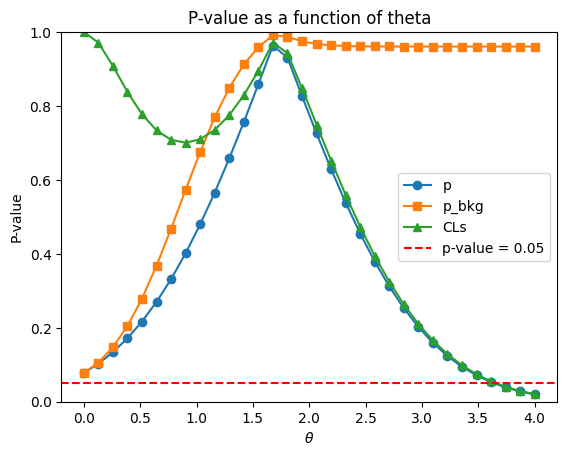

In [24]:
# Plot the p-value as a function of theta:
plt.plot(theta_values, p_values, marker='o', label='p')
plt.plot(theta_values, p_values_bkg, marker='s', label='p_bkg')
plt.plot(theta_values, cls_values, marker='^', label='CLs')
plt.axhline(0.05, color='red', linestyle='dashed', label='p-value = 0.05')
plt.xlabel(r'$\theta$')
plt.ylabel('P-value')
plt.title('P-value as a function of theta')
plt.ylim(0, 1)
plt.legend()
plt.show()

# Expected limits

- The expected limit is calculated by using the asimov dataset, which is the dataset that corresponds to the background-only prediction.

- The $\pm 1\sigma$ and $\pm 2\sigma$ expected limits can be calculated by using the asimov dataset and evaluating the quantile of the test statistic distribution under the background-only hypothesis that corresponds to the desired n_sigma value.

In [25]:
limits = {n_sigma: [] for n_sigma in [-2, -1, 0, 1, 2]} # will have n_sigma as keys
asimov = t0
for theta_val in theta_values:
    for n_sigma in [-2, -1, 0, 1, 2]:
        cls_value = cls(asimov, C, theta_val, n_sigma = n_sigma)
        limits[n_sigma].append(cls_value)

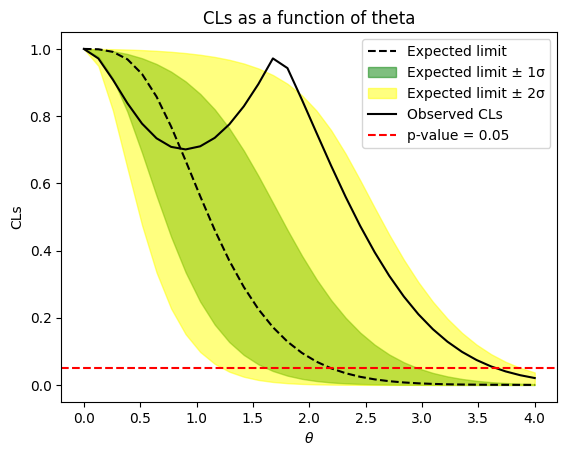

In [26]:
# Draw the expected limit as a black dashed line.
# Draw the +- 1 sigma and +/- 2 sigma expected limits as green and yellow bands, respectively.
# Draw the observed CLs values as a black solid line.
plt.plot(theta_values, limits[0], color='black', linestyle='dashed', label='Expected limit')
plt.fill_between(theta_values, limits[-1], limits[1], color='green', alpha=0.5, label='Expected limit ± 1σ')
plt.fill_between(theta_values, limits[-2], limits[2], color='yellow', alpha=0.5, label='Expected limit ± 2σ')
plt.plot(theta_values, cls_values, color='black', label='Observed CLs')
plt.axhline(0.05, color='red', linestyle='dashed', label='p-value = 0.05')
plt.xlabel(r'$\theta$')
plt.ylabel('CLs')
plt.title('CLs as a function of theta')
plt.legend()
plt.show()

# Upper limit on the signal strength

- The upper limit on the signal strength $\theta$ is the value of $\theta$ for which the p-value is equal to 0.05, as calculated in the hypothesis test inversion step.

- The present algorithm:

1. Go through the list of CLs values, starting from the highest index.
2. Check if the CLs value is less than 0.05.
3. If yes, then check if the next CLs value (at index lower by 1) is greater than 0.05.
4. If yes, then perform linear interpolation between these two points to find the value of $\theta$ for which the CLs value is equal to 0.05. This will give us the upper limit on $\theta$ at 95% confidence level.

In [27]:
def find_upper_limit(theta_values, cls_values):
    upper_limit = None
    i = len(theta_values) - 1
    while i > 0 and cls_values[i] < 0.05:
        if cls_values[i - 1] > 0.05:
            # Perform the linear interpolation.
            theta1 = theta_values[i - 1]
            theta2 = theta_values[i]
            cls1 = cls_values[i - 1]
            cls2 = cls_values[i]
            upper_limit = theta1 + (0.05 - cls1) * (theta2 - theta1) / (cls2 - cls1)
        i -= 1
    return upper_limit

obs_limit = find_upper_limit(theta_values, cls_values)
exp_limit = find_upper_limit(theta_values, limits[0])
print(f"Observed upper limit on theta at 95% CL: {obs_limit}")
print(f"Expected upper limit on theta at 95% CL: {exp_limit}")
for n_sigma in [-2, -1, 0, 1, 2]:
    limit = find_upper_limit(theta_values, limits[n_sigma])
    print(f"Expected upper limit on theta at 95% CL for n_sigma={n_sigma}: {limit}")

Observed upper limit on theta at 95% CL: 3.6566641418847796
Expected upper limit on theta at 95% CL: 2.1898896910310244
Expected upper limit on theta at 95% CL for n_sigma=-2: 3.878417143295415
Expected upper limit on theta at 95% CL for n_sigma=-1: 2.9630358056051085
Expected upper limit on theta at 95% CL for n_sigma=0: 2.1898896910310244
Expected upper limit on theta at 95% CL for n_sigma=1: 1.6220276496326997
Expected upper limit on theta at 95% CL for n_sigma=2: 1.2318028329284623
